# NSGA-II: быстрый элитарный многокритериальный генетический алгоритм

**Автор:** Ластовецкий Дмитрий, Университет ИТМО, Институт математики.

Реализация и эксперименты к докладу по статье:
> K. Deb, A. Pratap, S. Agarwal, T. Meyarivan.
> *A Fast and Elitist Multiobjective Genetic Algorithm: NSGA-II.*
> IEEE Transactions on Evolutionary Computation, 6(2), 2002.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from src.nsga2_core import (
    NSGAConfig,
    dominates,
    fast_non_dominated_sort,
    crowding_distance,
    assign_rank_and_distance,
    nsga2,
    sch, zdt1, zdt2, zdt3,
    true_front_sch, true_front_zdt1, true_front_zdt2, true_front_zdt3,
    convergence_metric, diversity_metric, get_first_front,
)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 1. Быстрая недоминируемая сортировка — $O(MN^2)$

(Deb et al. 2002, раздел III-A):

Для каждой точки $p$ вычисляем:
- $n_p$ — число точек, которые её доминируют (*счётчик доминирования*),
- $S_p$ — множество точек, которые доминирует $p$.

**Алгоритм:**

1. Первый фронт $\mathcal{F}_1 = \{p : n_p = 0\}$.
2. Для каждого $p \in \mathcal{F}_i$ и каждого $q \in S_p$: уменьшить $n_q$ на 1.
   Если $n_q = 0$, добавить $q$ в $\mathcal{F}_{i+1}$.
3. Повторять до исчерпания точек.

**Сложность:** два вложенных цикла дают $O(MN^2)$ (каждая из $O(N^2)$ пар требует $O(M)$ сравнений).

## 2. Расстояние толпы — $O(MN \log N)$

Для поддержания **разнообразия** вместо параметра $\sigma_{\mathrm{share}}$ NSGA-II использует
кубоидную оценку плотности.

**Алгоритм** для фронта $\mathcal{I}$ размера $l$:

1. Инициализировать $i_{\mathrm{distance}} = 0$ для всех $i$.
2. Для каждого критерия $m$:
   - Отсортировать по $f_m$.
   - Крайним точкам присвоить $i_{\mathrm{distance}} = \infty$.
   - Для остальных:
$$
i_{\mathrm{distance}} \mathrel{+}=
\frac{\mathcal{I}[i+1]_m - \mathcal{I}[i-1]_m}{f_m^{\max} - f_m^{\min}}.
$$

Физический смысл: $i_{\mathrm{distance}}$ — периметр кубоида, построенного на соседях точки $i$
по каждому критерию. Большое расстояние означает «менее заполненную» область.

In [2]:
# Пример расстояния толпы на одном фронте
tf = true_front_zdt1(10)  # 10 равномерных точек на фронте ZDT1
cd = crowding_distance(tf)
print("Точки фронта (f1, f2)  →  расстояние толпы:")
for i, (f, d) in enumerate(zip(tf, cd)):
    print(f"  [{i:2d}]  ({f[0]:.3f}, {f[1]:.3f})  →  {d:.4f}")

Точки фронта (f1, f2)  →  расстояние толпы:
  [ 0]  (0.000, 1.000)  →  inf
  [ 1]  (0.111, 0.667)  →  0.6936
  [ 2]  (0.222, 0.529)  →  0.4662
  [ 3]  (0.333, 0.423)  →  0.4175
  [ 4]  (0.444, 0.333)  →  0.3902
  [ 5]  (0.556, 0.255)  →  0.3721
  [ 6]  (0.667, 0.184)  →  0.3588
  [ 7]  (0.778, 0.118)  →  0.3485
  [ 8]  (0.889, 0.057)  →  0.3403
  [ 9]  (1.000, 0.000)  →  inf


## 3. Оператор сравнения с толпой $\prec_n$

Каждое решение $i$ имеет два атрибута: ранг $i_{\mathrm{rank}}$ (номер фронта) и
расстояние толпы $i_{\mathrm{distance}}$.

$$
i \prec_n j \iff
\begin{cases}
i_{\mathrm{rank}} < j_{\mathrm{rank}}, & \text{разные фронты;} \\
i_{\mathrm{rank}} = j_{\mathrm{rank}}\;\land\; i_{\mathrm{distance}} > j_{\mathrm{distance}},
& \text{одинаковый фронт: предпочитаем менее заполненную область.}
\end{cases}
$$

Этот оператор используется в **бинарном турнире** при отборе родителей
и при заполнении последнего фронта нового поколения.

## 4. Главный цикл NSGA-II

```
Инициализировать P_0 случайно, оценить F_0, отсортировать, назначить ранги и расстояния.

for t = 0, 1, 2, ...:
    Q_t  = make_new_pop(P_t)               # турнир → SBX → мутация
    R_t  = P_t ∪ Q_t                       # |R_t| = 2N
    F    = fast_non_dominated_sort(R_t)
    P_{t+1} = ∅
    for i = 1, 2, ...:
        if |P_{t+1}| + |F_i| ≤ N:
            P_{t+1} ← P_{t+1} ∪ F_i
        else:
            crowding_distance_assignment(F_i)
            Сортировать F_i по ↓ расстоянию толпы
            P_{t+1} ← P_{t+1} ∪ F_i[1 : N - |P_{t+1}|]
            break
    Q_{t+1} = make_new_pop(P_{t+1})
```

**Элитизм:** объединение $P_t \cup Q_t$ гарантирует, что лучшие решения не теряются.

**Сложность за поколение:**
- Недоминируемая сортировка: $O(MN^2)$.
- Назначение расстояний толпы: $O(MN \log N)$.
- Итого: $O(MN^2)$ — на порядок быстрее NSGA с $O(MN^3)$.

## 5. Генетические операторы

### Симулированное бинарное скрещивание (SBX)

Для каждой переменной $i$ с вероятностью $0.5$, при $x_1 < x_2$:

$$
\beta = 1 + \frac{2\min(x_1 - x_i^{\min},\, x_i^{\max} - x_2)}{x_2 - x_1},
\quad
\alpha = 2 - \beta^{-(\eta_c+1)},
$$

$$
\beta_q =
\begin{cases}
(u\,\alpha)^{1/(\eta_c+1)} & u \le 1/\alpha, \\
(1/(2 - u\,\alpha))^{1/(\eta_c+1)} & u > 1/\alpha,
\end{cases}
$$

$$
c_1 = \tfrac{1}{2}(x_1+x_2) - \tfrac{1}{2}\beta_q(x_2-x_1),
\quad
c_2 = \tfrac{1}{2}(x_1+x_2) + \tfrac{1}{2}\beta_q'(x_2-x_1).
$$

При большом $\eta_c$ потомки близки к родителям; при малом $\eta_c$ — широкий поиск.

### Полиномиальная мутация

Для каждой переменной с вероятностью $p_m = 1/n$:
$$
\delta_q =
\begin{cases}
(2u + (1-2u)(1-\delta_1)^{\eta_m+1})^{1/(\eta_m+1)} - 1 & u < 0.5, \\
1 - (2(1-u)+2(u-0.5)(1-\delta_2)^{\eta_m+1})^{1/(\eta_m+1)} & u \ge 0.5,
\end{cases}
$$
где $\delta_1 = (x-x^{\min})/(x^{\max}-x^{\min})$, $\delta_2 = (x^{\max}-x)/(x^{\max}-x^{\min})$.

## 6. Тестовые задачи

| Задача | $n$ | Фронт Парето | Особенность |
|--------|-----|-------------|------------|
| SCH | 1 | $f_2 = (\sqrt{f_1}-2)^2$ | простейший |
| ZDT1 | 30 | $f_2 = 1-\sqrt{f_1}$ | выпуклый |
| ZDT2 | 30 | $f_2 = 1-f_1^2$ | невыпуклый |
| ZDT3 | 30 | прерывистая кривая | разрывный |

Для ZDT1–3:
$$
f_1 = x_1,\quad
g(x) = 1 + \frac{9}{n-1}\sum_{i=2}^n x_i,\quad
f_2 = g(x)\cdot h(f_1, g).
$$

Оптимум достигается при $x_2 = \cdots = x_n = 0$ ($g = 1$).

In [3]:
cfg = NSGAConfig(pop_size=100, n_gen=250, seed=42)
cfg_sch = NSGAConfig(pop_size=50, n_gen=100, seed=1)

print("Запуск NSGA-II...")
histories = {}
problems = {
    'SCH':  (sch(),  cfg_sch),
    'ZDT1': (zdt1(30), cfg),
    'ZDT2': (zdt2(30), cfg),
    'ZDT3': (zdt3(30), cfg),
}
for name, ((objs, bounds), c) in problems.items():
    print(f"  {name}...", end=' ', flush=True)
    histories[name] = nsga2(objs, bounds, c)
    print("ok")

true_fronts = {
    'SCH':  true_front_sch(300),
    'ZDT1': true_front_zdt1(300),
    'ZDT2': true_front_zdt2(300),
    'ZDT3': true_front_zdt3(300),
}
print("Готово.")

Запуск NSGA-II...
  SCH... ok
  ZDT1... ok
  ZDT2... ok
  ZDT3... ok
Готово.


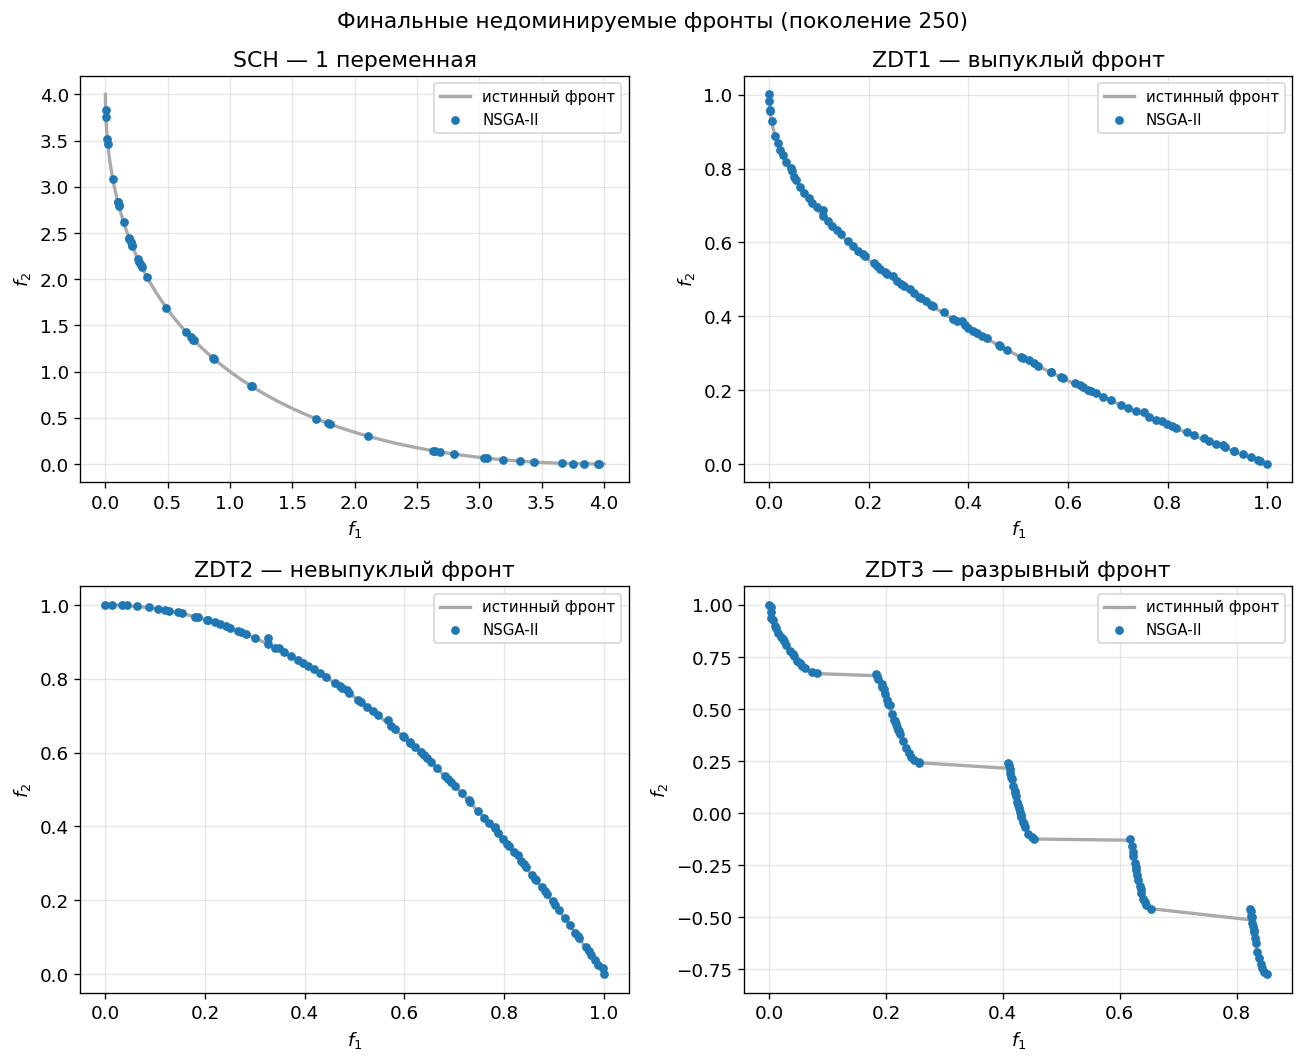

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
labels = {
    'SCH':  'SCH — 1 переменная',
    'ZDT1': 'ZDT1 — выпуклый фронт',
    'ZDT2': 'ZDT2 — невыпуклый фронт',
    'ZDT3': 'ZDT3 — разрывный фронт',
}
for ax, name in zip(axes.flat, ['SCH', 'ZDT1', 'ZDT2', 'ZDT3']):
    ff = get_first_front(histories[name], -1)
    tf = true_fronts[name]
    ax.plot(tf[:, 0], tf[:, 1], lw=2, color='#aaaaaa', label='истинный фронт')
    ax.scatter(ff[:, 0], ff[:, 1], s=18, color='#1f77b4', label='NSGA-II', zorder=3)
    ax.set_xlabel('$f_1$'); ax.set_ylabel('$f_2$')
    ax.set_title(labels[name]); ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.suptitle('Финальные недоминируемые фронты (поколение 250)', fontsize=13)
fig.tight_layout(); plt.show()

## 7. Эволюция популяции (ZDT1)

Посмотрим, как NSGA-II сходится к фронту Парето поколение за поколением.

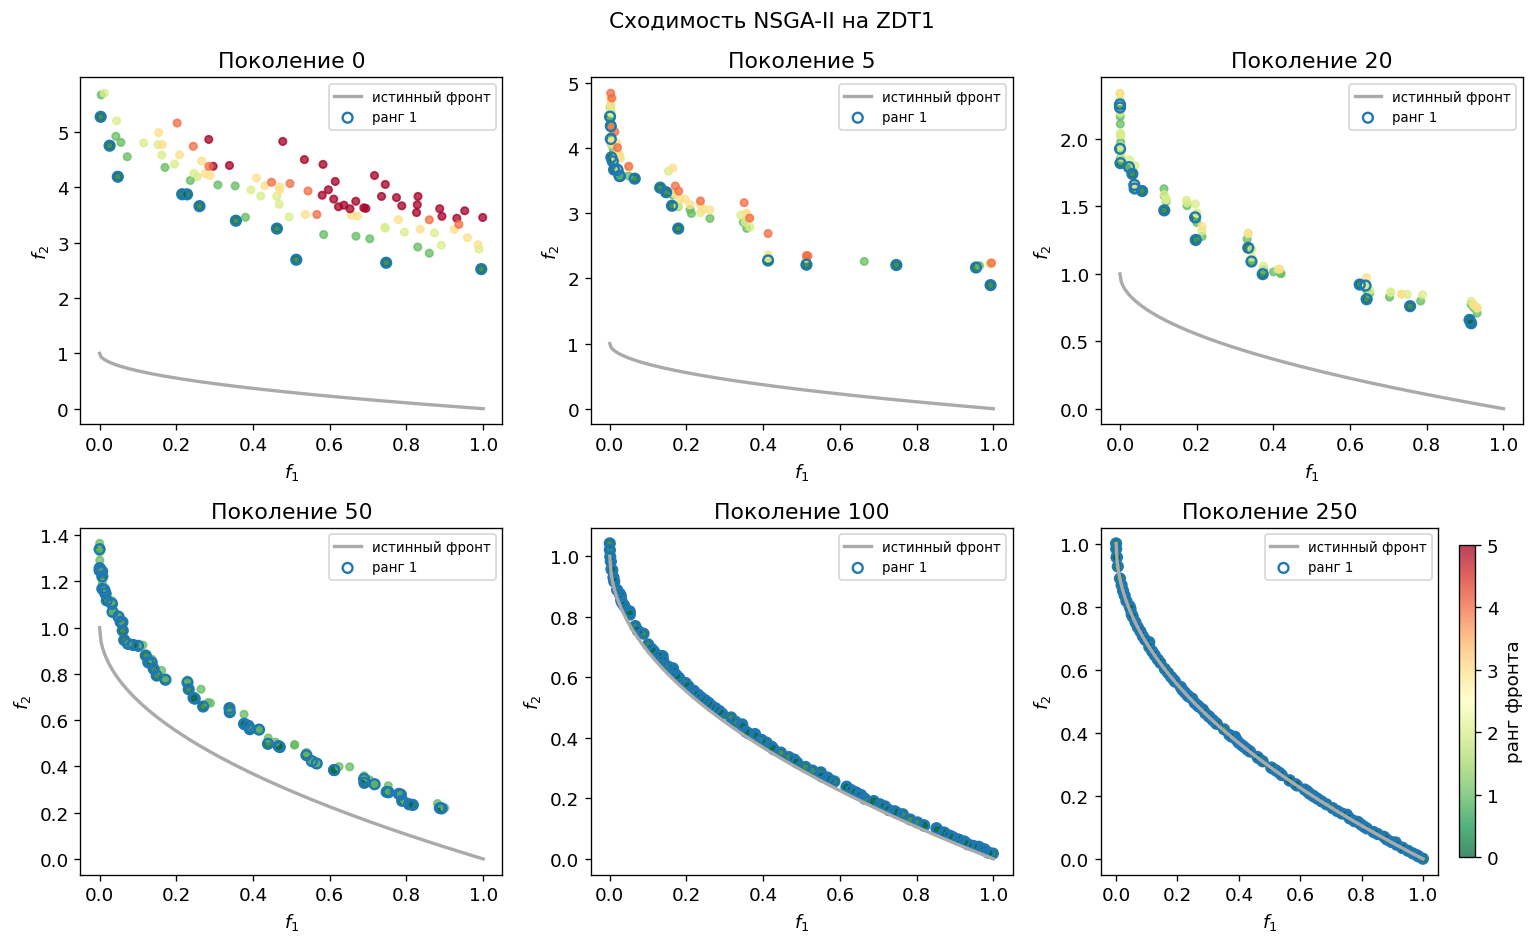

In [5]:
hist = histories['ZDT1']
tf = true_fronts['ZDT1']
gens_to_show = [0, 5, 20, 50, 100, 250]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, gen in zip(axes.flat, gens_to_show):
    F = hist['objectives'][gen]
    fronts = hist['fronts'][gen]
    front0 = np.array(fronts[0])
    ranks = np.zeros(len(F))
    for r, fr in enumerate(fronts):
        ranks[np.array(fr)] = r

    ax.plot(tf[:, 0], tf[:, 1], lw=2, color='#aaaaaa', label='истинный фронт')
    sc = ax.scatter(F[:, 0], F[:, 1], c=ranks, cmap='RdYlGn_r',
                    s=20, alpha=0.75, vmin=0, vmax=5)
    ax.scatter(F[front0, 0], F[front0, 1], s=35,
               edgecolors='#1f77b4', facecolors='none', lw=1.4, label='ранг 1')
    ax.set_xlabel('$f_1$'); ax.set_ylabel('$f_2$')
    ax.set_title(f'Поколение {gen}')
    ax.legend(fontsize=8)

fig.colorbar(sc, ax=axes.flat[-1], label='ранг фронта', shrink=0.9)
fig.suptitle('Сходимость NSGA-II на ZDT1', fontsize=13)
fig.tight_layout(); plt.show()

## 8. Метрики качества

### Метрика сходимости $\Upsilon$
Среднее минимальное расстояние от точек истинного фронта до полученного фронта:
$$
\Upsilon = \frac{1}{|H|}\sum_{h \in H} \min_{x \in \mathcal{F}} \|h - x\|_2.
$$
Чем меньше $\Upsilon$, тем ближе найденный фронт к истинному.

### Метрика разнообразия $\Delta$
Мера неравномерности распределения точек на фронте:
$$
\Delta = \frac{d_f + d_l + \sum_{i=1}^{N-1}|d_i - \bar{d}|}{d_f + d_l + (N-1)\bar{d}},
$$
где $d_i$ — евклидово расстояние между соседними точками, $d_f, d_l$ — расстояния до граничных точек
истинного фронта, $\bar{d}$ — среднее расстояние.

При $\Delta = 0$ точки равномерно покрывают весь фронт.

In [6]:
import pandas as pd

rows = []
for name, hist in histories.items():
    tf = true_fronts[name]
    ff_final = get_first_front(hist, -1)

    # metrics over all generations
    conv_curve, div_curve = [], []
    for gen in range(len(hist['objectives'])):
        ff = get_first_front(hist, gen)
        if len(ff) >= 2:
            conv_curve.append(convergence_metric(ff, tf))
            div_curve.append(diversity_metric(ff))

    rows.append({
        'задача': name,
        '|фронт|': len(ff_final),
        'Υ (финал)': round(conv_curve[-1], 6),
        'Δ (финал)': round(div_curve[-1], 4),
        'Υ (мин)': round(min(conv_curve), 6),
    })

pd.DataFrame(rows).set_index('задача')

,|фронт|,Υ (финал),Δ (финал),Υ (мин)
задача,,,,
SCH,47,0.076020,0.8077,0.076020
ZDT1,100,0.004950,0.3566,0.004804
ZDT2,100,0.004770,0.3643,0.004770
ZDT3,100,0.004763,0.5395,0.004720


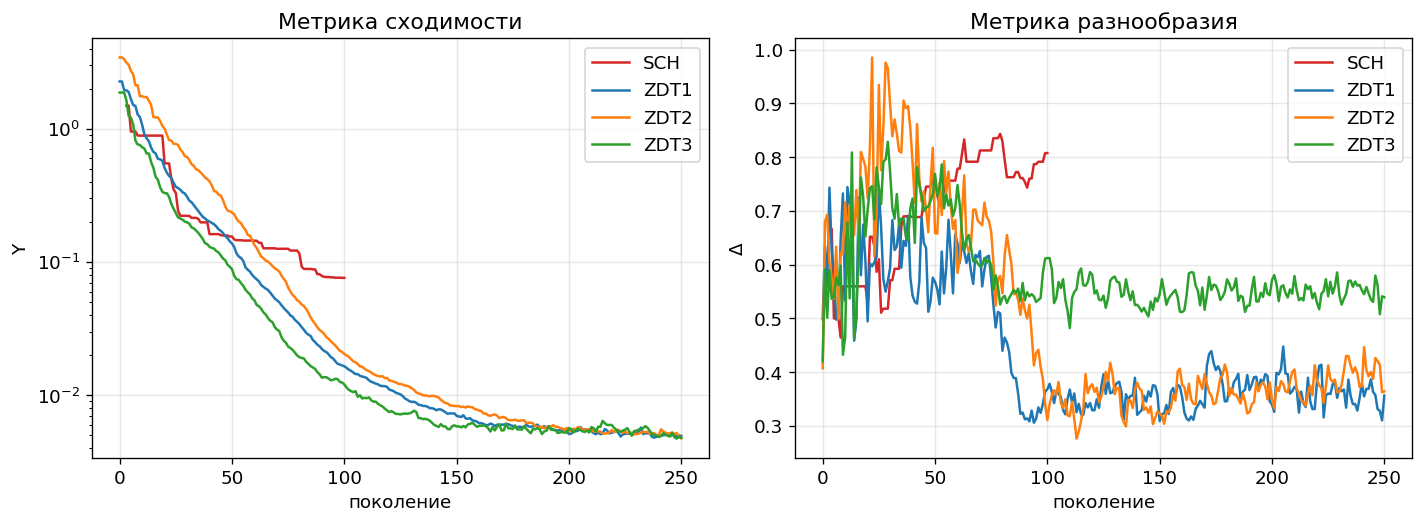

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {'SCH': '#d62728', 'ZDT1': '#1f77b4', 'ZDT2': '#ff7f0e', 'ZDT3': '#2ca02c'}

for name, hist in histories.items():
    tf = true_fronts[name]
    conv, div = [], []
    for gen in range(len(hist['objectives'])):
        ff = get_first_front(hist, gen)
        if len(ff) >= 2:
            conv.append(convergence_metric(ff, tf))
            div.append(diversity_metric(ff))
        else:
            conv.append(np.nan); div.append(np.nan)
    gens = np.arange(len(conv))
    axes[0].plot(gens, conv, label=name, color=colors[name])
    axes[1].plot(gens, div, label=name, color=colors[name])

for ax, (ylabel, title, scale) in zip(axes, [
    (r'$\Upsilon$', 'Метрика сходимости', 'log'),
    (r'$\Delta$', 'Метрика разнообразия', 'linear'),
]):
    ax.set_xlabel('поколение'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    if scale == 'log': ax.set_yscale('log')

fig.tight_layout(); plt.show()

## 9. Почему NSGA-II работает

| Свойство | Механизм |
|----------|----------|
| **Элитизм** | $R_t = P_t \cup Q_t$: лучшие решения никогда не теряются |
| **Разнообразие** | Расстояние толпы вместо параметрического $\sigma_{\mathrm{share}}$ |
| **Сходимость** | Недоминируемая сортировка направляет поиск к фронту Парето |
| **Масштабируемость** | $O(MN^2)$ вместо $O(MN^3)$ у NSGA |

**Чего нет:** строгих гарантий сходимости к истинному фронту Парето для произвольных задач.
Алгоритм стохастический — результаты разных запусков могут отличаться.

## 10. Устойчивость: несколько запусков на ZDT1

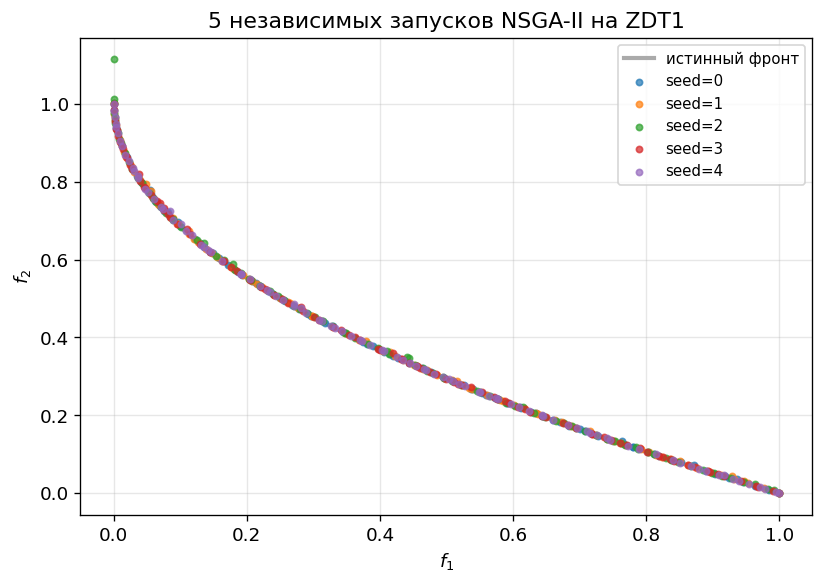

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
tf = true_fronts['ZDT1']
ax.plot(tf[:, 0], tf[:, 1], lw=2.5, color='#aaaaaa', label='истинный фронт', zorder=1)

objs_zdt1, bounds_zdt1 = zdt1(30)
for seed in range(5):
    h = nsga2(objs_zdt1, bounds_zdt1, NSGAConfig(pop_size=100, n_gen=250, seed=seed))
    ff = get_first_front(h, -1)
    ax.scatter(ff[:, 0], ff[:, 1], s=14, alpha=0.7, label=f'seed={seed}', zorder=3)

ax.set_xlabel('$f_1$'); ax.set_ylabel('$f_2$')
ax.set_title('5 независимых запусков NSGA-II на ZDT1')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Вывод

NSGA-II за счёт трёх нововведений решает три главных проблемы NSGA:

1. **Быстрая недоминируемая сортировка** $O(MN^2)$ вместо $O(MN^3)$.
2. **Расстояние толпы** — параметронезависимая оценка плотности для равномерного покрытия фронта.
3. **Оператор $\prec_n$** — единый критерий отбора, совмещающий качество (ранг) и разнообразие.

В экспериментах на задачах ZDT алгоритм находит хорошо распределённые решения,
близкие к истинному фронту Парето, без ручной настройки параметров разнообразия.